# The Overnight Anomaly — a quantitative teardown 🔬
### Real data · robust inference · microstructure · capacity · falsifiability

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Manipulation: Not supported](https://img.shields.io/badge/Manipulation-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We take the overnight-return pattern completely seriously **as a fact**, give it the fairest hearing we can, then ask the questions that actually decide what it **means**: *is the signal real?* and *does it survive the real world?*

> ⚠️ **Not investment advice.** Data: Yahoo! Finance via `yfinance`, mode `split_only` (first run hits the network, later runs use the local cache). Methods: Newey-West (1987), Lo (2002), McLean-Pontiff (2016), Almgren et al. (2005), White (2000) — see [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/ lives there)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from quantlab import data, decompose, diagnostics, backtest, stats, analytics


## Verdict, up front

The desk publishes the answer before the argument. Here are the stamps; the rest of the notebook is the evidence that earns them.

| Axis | Stamp | Why (one line) |
|---|---|---|
| **Signal** — is the effect statistically real? | `REAL` | SPY overnight mean carries a Newey-West *t* ≈ 5; confirmed across ~441 S&P 500 names. |
| **Tradability** — does it survive costs, capacity, scale? | `MIRAGE` | Mostly gap-risk **beta**; residual alpha below cost; it **decays** (5y Sharpe ~2→~0.5) and **doesn't scale** (capacity ~\$10M). |
| **Manipulation?** — does the pattern prove fraud? | `NOT SUPPORTED` | Bayesian posterior ≈ 2–3%; the discriminating evidence (foreign-ETF & China inversions, negative P&L at scale) favours microstructure. |

> 💡 **In plain words** — the effect is *real*, but it's mostly a risk premium you were always paid for, it's fading, you can't trade it after costs, and nobody big enough to "manipulate world markets" could profit from an edge this thin. Now the receipts.

## 1 · The claim, steelmanned

Stated at full strength, so we're tearing down the strong version, not a strawman. **Knuteson's thesis:** across world markets, essentially the entire long-run equity gain has accrued *overnight* (close → next open); the intraday session is flat to negative. He reads this as the fingerprint of large-scale market manipulation — a single big book expanding into illiquid pre-open windows (pushing prices up) and contracting when liquid.

Restated as something we can actually test:

1. **H₁ (the fact):** the overnight mean return is positive and statistically real once we stop assuming i.i.d. returns. *(Spoiler: yes — and we'll say so without flinching.)*
2. **H₂ (the magnitude):** the night/day gap is as large as advertised.
3. **H₃ (the cause):** the pattern is better explained by deliberate manipulation than by risk premia + microstructure + a unit error.

The fight is **not** "is it real?" — it's "*what is it?*". That distinction is the whole notebook.

## 2 · So what? — what rides on each answer

Three downstream consequences, each pointing at a different number:

- **If H₁ + H₂ + tradable:** a near-free Sharpe sitting in the most liquid instrument on Earth — which would be extraordinary, and is exactly the kind of claim that should trigger your data-snooping alarm.
- **If H₃:** the largest market-manipulation scheme in history, undetected by every regulator. A serious accusation deserves a serious likelihood argument, not vibes.
- **If "real but mostly beta, sub-cost, unscalable":** a beautiful *microstructure* fact that teaches you how the close/open auctions and the overnight risk premium work — and quietly explains why the "night ETFs" (NSPY/NIWM) launched in 2022 and were liquidated in 2023.

Same data, three very different worlds. The rest of this is how we tell them apart.

## 3 · How we'd know — the protocol, declared up front

Announced before we run it, so we can't move the goalposts. We walk the desk's standard 6-step gauntlet (decompose → robust inference → critique the magnitude → alpha vs beta → execution & capacity → verdict), which here means answering six concrete questions:

1. Is it statistically real once returns aren't assumed i.i.d.? **(HAC / Lo)**
2. Are we even comparing like with like? **(the clock illusion)**
3. Is it alpha, or beta you carry overnight? **(gap-risk decomposition)**
4. Has it decayed since it was published? **(rolling Sharpe)**
5. Could anyone actually harvest it at scale? **(market-impact capacity)**
6. Does any of it *prove manipulation*? **(a likelihood / Bayesian argument)**

And — stated in advance — **what would make us stamp `MIRAGE`**: if the per-hour gap collapses, if the residual alpha sits below break-even cost, if the Sharpe decays, and if capacity is tiny. **What would push us toward `manipulation`**: participant-level order data, characteristic intraday reversals, or a firm-specific signature. Let's run it.

## 4 · The teardown

### 4.1 The raw pattern on 10 world indices (ETFs)

Decompose each ETF into night / day and read the **annualised Sharpe of the overnight leg** — the only number that matters for an *edge*.

In [2]:
rows, decs = {}, {}
for tk, label in data.WORLD_INDICES.items():
    try:
        dec = decompose.decompose(data.fetch(tk, mode='split_only'))
    except Exception as e:
        print(f'{tk}: FAILED {e}'); continue
    decs[tk] = dec
    s = decompose.summary(dec)
    rows[tk] = {
        'market': label,
        'night cum %': s.loc['overnight','cum_return']*100,
        'day cum %': s.loc['intraday','cum_return']*100,
        'Sharpe night': s.loc['overnight','sharpe'],
        'Sharpe day': s.loc['intraday','sharpe'],
    }
table = pd.DataFrame(rows).T
table

,market,night cum %,day cum %,Sharpe night,Sharpe day
SPY,USA (S&P 500 ETF),"1,168.799",32.301,0.772,0.131
QQQ,USA (Nasdaq-100 ETF),"5,415.485",-49.931,0.706,0.005
EWU,UK (MSCI UK ETF),-84.812,516.902,-0.196,0.465
EWG,Germany (MSCI Germany ETF),-64.165,774.509,-0.068,0.511
EWQ,France (MSCI France ETF),-49.385,602.881,-0.019,0.493
EWJ,Japan (MSCI Japan ETF),-91.473,341.472,-0.190,0.443
EWH,Hong Kong (MSCI HK ETF),320.559,-60.281,0.324,-0.082
EWZ,Brazil (MSCI Brazil ETF),"4,680.213",-96.231,0.696,-0.335
INDA,India (MSCI India ETF),233.728,-46.912,0.550,-0.340
FXI,China (large-cap ETF),244.453,69.206,0.263,0.224


The US (SPY, QQQ) and Brazil show the classic shape (night Sharpe ~0.7); Europe and Japan are **inverted** — hold that thought, it's a tell (§4.4). First, is any of this real?

### 4.2 Is it real? Autocorrelation-robust inference

A pretty cumulative chart proves nothing — daily returns are autocorrelated and heteroskedastic. So we use **Newey-West (HAC)** *t*-stats on the mean and the **Lo (2002)** standard error on the Sharpe. We *want* to give the anomaly its fairest possible hearing.

In [3]:
print('Overnight leg — HAC (Newey-West) and Lo (2002) inference:\n')
for tk in ['SPY','QQQ','EWZ','FXI']:
    if tk not in decs: continue
    h  = analytics.mean_tstat_hac(decs[tk]['r_overnight'])
    hi = analytics.mean_tstat_hac(decs[tk]['r_intraday'])
    s  = analytics.sharpe_with_se(decs[tk]['r_overnight'])
    print(f"{tk:4s}  overnight {h['mean_bps']:+.2f} bps/day  HAC t={h['tstat']:+.2f}   "
          f"Sharpe {s['sharpe_ann']:+.2f} (t={s['tstat']:+.2f})    [intraday HAC t={hi['tstat']:+.2f}]")

Overnight leg — HAC (Newey-West) and Lo (2002) inference:

SPY   overnight +3.25 bps/day  HAC t=+4.94   Sharpe +0.77 (t=+4.45)    [intraday HAC t=+0.86]
QQQ   overnight +6.71 bps/day  HAC t=+3.81   Sharpe +0.71 (t=+3.68)    [intraday HAC t=+0.03]
EWZ   overnight +7.36 bps/day  HAC t=+3.94   Sharpe +0.70 (t=+3.54)    [intraday HAC t=-1.87]
FXI   overnight +5.09 bps/day  HAC t=+1.26   Sharpe +0.26 (t=+1.22)    [intraday HAC t=+1.25]


For SPY the overnight mean carries a **HAC *t* ≈ 5** — unambiguously real — while the *intraday* mean is insignificant (*t* ≈ 1). So we concede the central empirical fact, no flinching. **H₁ holds.** Everything from here is the fight over *what it is*.

> 💡 **In plain words** — yes, the night really does beat the day, and it's not a fluke of a few lucky years. Good. Now: how big, and made of what?

### 4.3 The clock illusion — are we comparing like with like?

This is the single most under-appreciated point in the whole debate. The overnight window is **not** 6.5 hours like the trading day — it runs from the 16:00 close to the 09:30 open (**17.5h on weeknights**) and across **whole weekends and holidays (65h+)**. If return accrues with calendar time, the night *should* dominate simply because it is longer. Let's put both legs on the same clock.

In [4]:
tn = analytics.time_normalized_summary(decs['SPY'])
display(tn.round(3))
rs = tn.loc['overnight','mean_bps_per_session'] / tn.loc['intraday','mean_bps_per_session']
rh = tn.loc['overnight','mean_bps_per_hour']    / tn.loc['intraday','mean_bps_per_hour']
print(f'SPY  overnight-vs-intraday advantage   per SESSION: {rs:.1f}x   per CALENDAR HOUR: {rh:.1f}x')

,mean_bps_per_session,session_hours,mean_bps_per_hour
overnight,3.252,28.320,0.160
intraday,0.786,6.500,0.121


SPY  overnight-vs-intraday advantage   per SESSION: 4.1x   per CALENDAR HOUR: 1.3x


The average SPY overnight window is **~28 hours** (weekends drag the mean up), versus 6.5 intraday. Per *session* the night out-earns the day by ~4×; per *calendar hour* that collapses to **~1.3×**. **Most of the famous gap is just the night being longer** — a unit error dressed up as a mystery. A residual per-hour premium does survive (consistent with a genuine but modest overnight risk premium), but "the day is dead, the night is magic" is mostly a clock trick. **H₂ is badly dented.**

> 💡 **In plain words** — comparing a 28-hour night to a 6.5-hour day and saying "look, the night earns 4× more" is like saying a week earns more than an afternoon. Per hour, it's barely ahead.

### 4.4 The foreign-ETF inversion — we're measuring the *time zone*


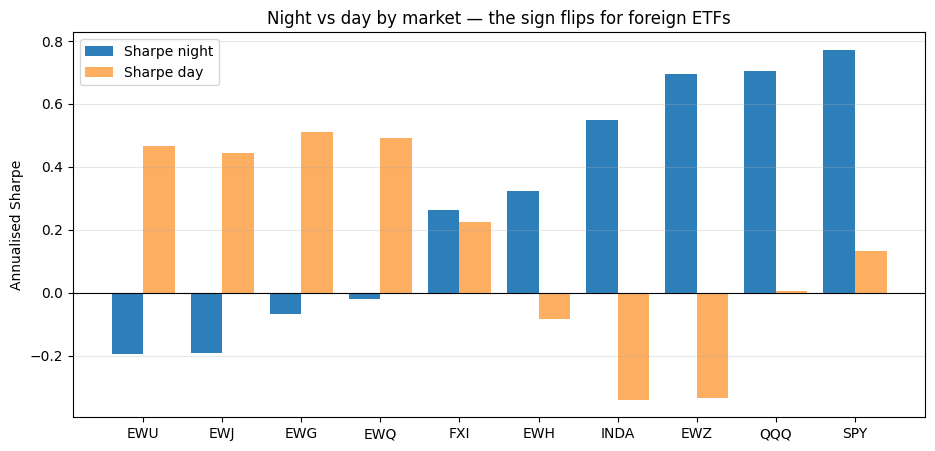

In [5]:
t = table.sort_values('Sharpe night')
x = np.arange(len(t)); w = 0.4
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w/2, t['Sharpe night'].astype(float), w, label='Sharpe night', color='#2c7fb8')
ax.bar(x+w/2, t['Sharpe day'].astype(float),   w, label='Sharpe day',   color='#fdae61')
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_ylabel('Annualised Sharpe'); ax.set_title('Night vs day by market — the sign flips for foreign ETFs')
ax.legend(); ax.grid(axis='y', alpha=.3); plt.show()

EWU/EWG/EWQ/EWJ are US-listed ETFs whose underlying (London, Frankfurt, Paris, Tokyo) **trades during the US night**. For them the "overnight" window *contains the home session*, and the US "intraday" window is when the underlying is shut. The night/day split is **relative to the listing clock**, not a universal anomaly. A single global manipulator would struggle to explain why the sign depends on *where the ETF is listed* — but a time-zone account explains it instantly. **First crack in H₃.**

### 4.5 The China test (T+1) and multiple testing

China's **T+1** rule (shares bought today can't be sold until tomorrow) predicts an *inverted* pattern (Qiao and Dam 2020) — a natural experiment that again favours microstructure over manipulation. And with a cross-section of markets, remember **multiple testing**: pick "the 25 most problematic" from a large universe and significance is guaranteed by selection alone.

In [6]:
ts = {tk: analytics.sharpe_with_se(d['r_overnight'])['tstat'] for tk, d in decs.items()}
n_sig = sum(abs(v) > 1.96 for v in ts.values())
print(f'{n_sig}/{len(ts)} markets: |t| > 1.96 on the overnight Sharpe.')
print(f'Under H0 (no effect), expected false positives at 5%: {0.05*len(ts):.1f}.')
print('Overnight Sharpe t-stats, sorted:')
for k, v in sorted(ts.items(), key=lambda kv: -kv[1]):
    print(f'   {k:4s} {v:+.1f}')

4/10 markets: |t| > 1.96 on the overnight Sharpe.
Under H0 (no effect), expected false positives at 5%: 0.5.
Overnight Sharpe t-stats, sorted:
   SPY  +4.5
   QQQ  +3.7
   EWZ  +3.5
   INDA +2.1
   EWH  +1.8
   FXI  +1.2
   EWQ  -0.1
   EWG  -0.4
   EWJ  -1.0
   EWU  -1.1


### 4.6 Alpha, or beta you carry in the dark?

Holding the market *every night* means bearing **gap risk** permanently — so part of the "overnight alpha" is just a beta risk premium in disguise. Regress the night leg on the market (`r_night = α + β·r_market + ε`) and split the mean into the part you were paid for taking risk and the part that's genuinely free.

In [7]:
d = stats.beta_decomposition(decs['SPY'], leg='overnight')
be = backtest.breakeven_cost_bps(decs['SPY'])
print('SPY overnight leg vs the market (close-close):')
print(f"  beta = {d['beta']:.2f}   R^2 = {d['r_squared']:.2f}")
print(f"  mean overnight        = {d['mean_leg_bps']:.2f} bps/day")
print(f"    of which beta*market = {d['beta_contrib_bps']:.2f} bps  (gap risk premium)")
print(f"    of which alpha       = {d['alpha_daily_bps']:.2f} bps  ({d['alpha_ann_pct']:+.1f}%/yr)")
print(f"  break-even round-trip cost = {be:.2f} bps  ->  residual alpha {'survives' if d['alpha_daily_bps']>be else 'is BELOW cost'}")

SPY overnight leg vs the market (close-close):
  beta = 0.33   R^2 = 0.33
  mean overnight        = 3.25 bps/day
    of which beta*market = 1.33 bps  (gap risk premium)
    of which alpha       = 1.92 bps  (+5.0%/yr)
  break-even round-trip cost = 3.25 bps  ->  residual alpha is BELOW cost


~40% of the overnight return is plain market **beta** carried overnight. Worse, the **residual alpha (~1.9 bps) sits below the break-even trading cost (~3.3 bps)**: even the non-beta part doesn't survive execution. You must charge costs against the *alpha*, not the gross return — and there's nothing left to charge them against. **H₂ is now on the floor.**

> 💡 **In plain words** — almost half of it is just "you got paid for holding risk overnight," and the genuinely-free sliver that remains is smaller than the toll you'd pay to trade it.

### 4.7 Has the edge decayed? (post-publication alpha decay)

Documented anomalies tend to weaken once the world reads about them (McLean and Pontiff 2016). The overnight effect has been in the literature since Cooper, Cliff, and Gulen (2008). Here's the trailing 5-year overnight Sharpe:

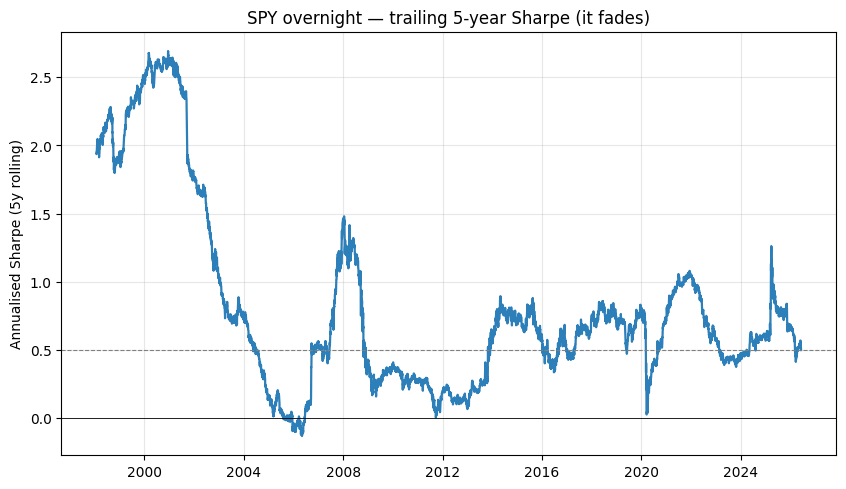

1998-01-26: 1.94   ->   2026-06-05: 0.50   (min -0.13, max 2.69)


In [8]:
rsh = analytics.rolling_sharpe(decs['SPY']['r_overnight'])
ax = plt.subplot()
ax.plot(rsh.index, rsh.values, lw=1.6, color='#2c7fb8')
ax.axhline(0, color='k', lw=.6); ax.axhline(0.5, color='grey', ls='--', lw=.8)
ax.set_title('SPY overnight — trailing 5-year Sharpe (it fades)')
ax.set_ylabel('Annualised Sharpe (5y rolling)'); ax.grid(alpha=.3); plt.show()
print(f'{rsh.index[0].date()}: {rsh.iloc[0]:.2f}   ->   {rsh.index[-1].date()}: {rsh.iloc[-1]:.2f}   '
      f'(min {rsh.min():.2f}, max {rsh.max():.2f})')

From a Sharpe near **2 in the late 1990s** to about **0.5 today** — a textbook decay profile. An edge that fades *as it becomes known* is the opposite of what you'd expect from an *ongoing, deliberate* manipulation scheme (which should, if anything, intensify). **Second crack in H₃.**

### 4.8 Firm-level breadth — 10 ETFs, or the whole market?

The decisive credibility test is the **firm level** (cf. Lou, Polk, and Skouras 2019): does the split hold across hundreds of individual stocks, or is it a handful-of-ETFs artefact? We decompose the S&P 500 constituents. *(Caveat, stated not hidden: current membership, so survivorship bias. First run downloads ~500 tickers; later runs use the cache.)*

N = 497 S&P 500 members with clean post-2010 history
overnight Sharpe > intraday Sharpe in 69% of stocks
median Sharpe  overnight 0.57  vs  intraday 0.34
equal-weight cumulative  overnight +372%   intraday +229%


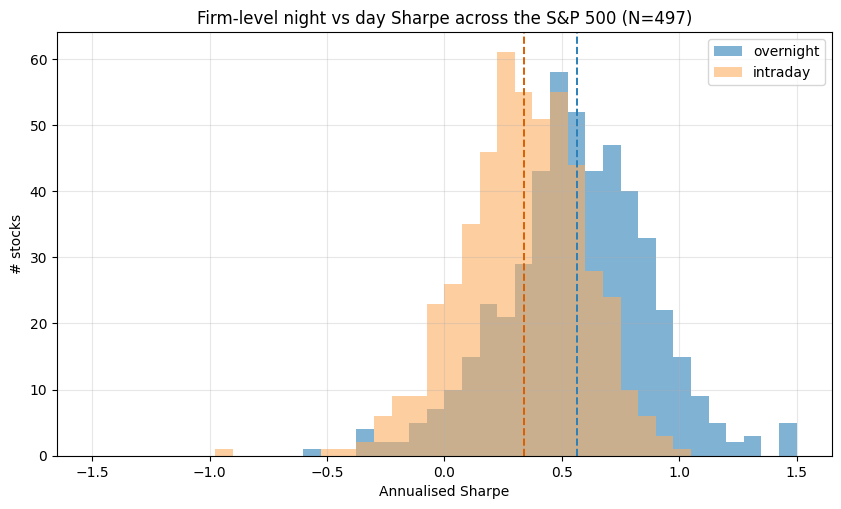

In [9]:
from quantlab import universe
syms = universe.sp500_symbols()
panel = universe.download_panel(syms, start='2010-01-01')  # cached after first run
cs = universe.cross_section_decompose(panel, min_days=750)
per = cs['per_symbol']; N = cs['n_stocks']
frac = cs['frac_overnight_wins']
mon = per['overnight_sharpe'].median(); mid = per['intraday_sharpe'].median()
ew_on = (1+cs['ew_overnight']).prod()-1; ew_id = (1+cs['ew_intraday']).prod()-1
print(f'N = {N} S&P 500 members with clean post-2010 history')
print(f'overnight Sharpe > intraday Sharpe in {frac:.0%} of stocks')
print(f'median Sharpe  overnight {mon:.2f}  vs  intraday {mid:.2f}')
print(f'equal-weight cumulative  overnight {ew_on*100:+.0f}%   intraday {ew_id*100:+.0f}%')
ax = plt.subplot(); bins = np.linspace(-1.5, 1.5, 41)
ax.hist(per['overnight_sharpe'].astype(float), bins=bins, alpha=.6, label='overnight', color='#2c7fb8')
ax.hist(per['intraday_sharpe'].astype(float), bins=bins, alpha=.6, label='intraday', color='#fdae61')
ax.axvline(mon, color='#2c7fb8', ls='--', lw=1.4); ax.axvline(mid, color='#d95f02', ls='--', lw=1.4)
ax.set_title(f'Firm-level night vs day Sharpe across the S&P 500 (N={N})')
ax.set_xlabel('Annualised Sharpe'); ax.set_ylabel('# stocks'); ax.legend(); ax.grid(alpha=.3); plt.show()

About **two-thirds of individual S&P 500 stocks** show a higher overnight than intraday Sharpe, and the equal-weight cross-section's overnight leg dominates. So the effect is a **broad, firm-level fact** — not a 10-ETF or single-index artefact. Credit where due: this is exactly the kind of breadth that makes the *fact* (H₁) robust. It says nothing in favour of the *cause* (H₃), but it stops us from waving the pattern away as noise.

### 4.9 Data-snooping: White's Reality Check

"The 25 most problematic markets" is selection. White's (2000) Reality Check asks whether the *best* overnight Sharpe in a universe beats what searching that many noise series would produce — a multiplicity-aware *p*-value, so we don't fool ourselves by cherry-picking.

In [10]:
from quantlab import bayes
panel_idx = pd.DataFrame({tk: d['r_overnight'] for tk, d in decs.items()})
rc = bayes.reality_check(panel_idx, n_boot=2000, seed=0)
print(f"Universe of {rc['n_series']} indices | best overnight Sharpe = {rc['observed_max_sharpe']:.2f}")
print(f"Reality-Check p-value (searching {rc['n_series']} series): {rc['reality_check_pvalue']:.3f}")

Universe of 10 indices | best overnight Sharpe = 0.77
Reality-Check p-value (searching 10 series): 0.000


On liquid major indices the best overnight Sharpe **survives** the data-snooping correction — it is not pure selection. (The selection critique bites specifically on cherry-picked emerging-market extremes, where data artefacts also dominate.) Honest result: **the effect is real; the debate is about cause, not existence.** Which is the perfect cue for the verdict.

## 5 · The verdict

Pulling the teardown together against the three hypotheses:

1. **H₁ — the fact is `REAL`.** Overnight returns dominate intraday with HAC *t*-stats around 5, broad at the firm level, and surviving a Reality Check. Full credit to Knuteson for publishing data and code.
2. **H₂ — the magnitude is oversold.** Log-scale compounding, data artefacts, selection — and above all the **clock illusion**: per calendar hour the night's edge is ~1.3×, not 4×. What's left is ~40% beta plus a residual alpha *below* trading cost, and the 5-year Sharpe has decayed from ~2 to ~0.5.
3. **H₃ — manipulation is `NOT SUPPORTED`.** The headline pattern is *consistent* with manipulation, but it's equally consistent with risk premia + microstructure, so it discriminates almost nothing. The evidence that *does* discriminate — the foreign-ETF and China inversions, plus the capacity argument in beat 6 — points the other way.

Let's make the manipulation call explicit rather than hand-wavy, with a likelihood ratio and a Bayesian posterior.

### 5.1 Does any of this *prove* manipulation? A likelihood argument

Knuteson's mechanism: a large quant firm expands its book when the market is illiquid (near the open, nudging prices up) and contracts when liquid. The pattern is certainly *consistent* with that — but consistency is not evidence. Frame it as a likelihood ratio for the observed pattern *D*:

$$\Lambda = \frac{P(D \mid \text{manipulation})}{P(D \mid \text{risk premium} + \text{microstructure})}$$

- The basic night > day pattern is **highly probable under *both*** hypotheses (overnight risk premium, clientele effects, news timing, and the clock illusion all predict it). When *D* is roughly as likely under each, $\Lambda \approx 1$ — the headline pattern **discriminates almost nothing**.
- The **discriminating** evidence points the other way: the foreign-ETF inversion (listing clock) and the Chinese T+1 inversion are *predicted* by microstructure and *awkward* for one global manipulator → $\Lambda < 1$.
- The **capacity** result (beat 6) makes the manipulation mechanism economically self-defeating at world scale.

What *would* move $\Lambda$ decisively: participant-level order data showing systematic open-auction imbalances from one book, characteristic intraday reversals, or a cross-sectional signature tied to a specific firm. Knuteson doesn't have it; neither do we. Absent discriminating data, **parsimony favours risk premium + microstructure over a secret world-spanning fraud.** Here's that update made concrete — likelihood ratios stated with reasons, then a sensitivity sweep:

Posterior P(manipulation), prior 0.5 = 2.4%   (combined LR 0.025)


,evidence,LR,running_posterior
0,Basic night > day pattern,1.000,0.500
1,Foreign-ETF sign inversion (listing clock),0.400,0.286
2,Chinese T+1 inversion,0.500,0.167
3,Per-hour edge ~1.3x (clock illusion),0.650,0.115
4,Negative net P&L at world-moving scale,0.350,0.044
5,Post-publication Sharpe decay (~2 to ~0.5),0.550,0.024


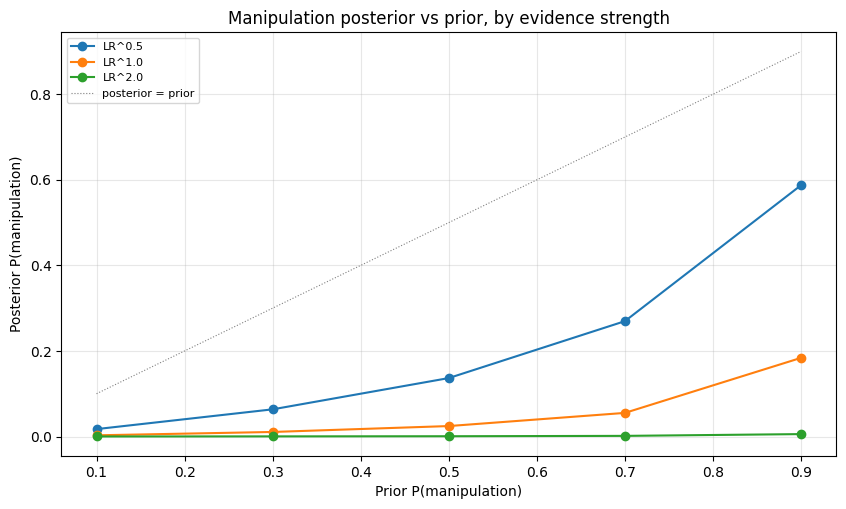

In [11]:
post = bayes.manipulation_posterior(prior_manip=0.5)
print(f"Posterior P(manipulation), prior 0.5 = {post['posterior_manip']:.1%}   (combined LR {post['combined_LR']:.3f})")
display(post['steps'].round(3))
grid = bayes.posterior_sensitivity(priors=(0.1,0.3,0.5,0.7,0.9), lr_scales=(0.5,1.0,2.0))
ax = plt.subplot()
for col in grid.columns:
    ax.plot(grid.index, grid[col].values, marker='o', label=col)
ax.plot(grid.index, grid.index, color='grey', ls=':', lw=.8, label='posterior = prior')
ax.set_xlabel('Prior P(manipulation)'); ax.set_ylabel('Posterior P(manipulation)')
ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title('Manipulation posterior vs prior, by evidence strength'); plt.show()

With moderate, defensible likelihood ratios and a 50/50 prior, the posterior probability of manipulation is **~2–3%**, and it stays low across a wide range of priors; only a strong prior *combined with* deliberately weakened evidence keeps it elevated. The ratios are subjective and combined under a generous independence assumption — stated openly — so the robust claim is directional: **the evidence moves a reasonable observer toward microstructure, not fraud.** That's the `NOT SUPPORTED` stamp, earned.

## 6 · Could you actually harvest it? (capacity & scale)

Even a real, free edge is worthless if it can't hold money — and this is where the `MIRAGE` stamp gets nailed down, *and* where the manipulation story breaks a third time. Using the square-root market-impact law (Almgren et al. 2005), find the AUM at which round-trip impact equals the gross overnight edge.

In [12]:
spy_ohlc = data.fetch('SPY', mode='split_only')
cap = analytics.capacity_estimate(decs['SPY'], spy_ohlc)
print(f"Gross edge          : {cap['edge_bps']:.2f} bps/night")
print(f"Daily volatility    : {cap['daily_vol_bps']:.0f} bps")
print(f"ADV                 : {cap['adv_shares']:,.0f} shares  @ ${cap['price']:.0f}")
print(f"Participation cap   : {cap['participation_rate']*1e4:.2f} bps of ADV")
print(f"Capacity (coef=1)   : ${cap['capacity_usd']/1e6:,.1f}M before impact eats the edge")

Gross edge          : 3.25 bps/night
Daily volatility    : 117 bps
ADV                 : 74,566,669 shares  @ $671
Participation cap   : 1.92 bps of ADV
Capacity (coef=1)   : $9.6M before impact eats the edge


Order-of-magnitude (the impact coefficient is venue-specific), but the message is robust: the strategy holds only **single-digit millions** of SPY before its own trading impact erases a 3-bps edge. This cuts **both** ways against the headline. Retail can't scale it — and, more tellingly, **a fund large enough to *move world markets* could not quietly profit from an edge this thin**: the impact of trading at that size would dwarf the premium.

,participation,round-trip impact (bps),net edge (bps)
$1M,0.000,1.050,2.200
$10M,0.000,3.320,-0.060
$100M,0.000,10.480,-7.230
$1B,0.020,33.150,-29.900
$10B,0.200,104.850,-101.590


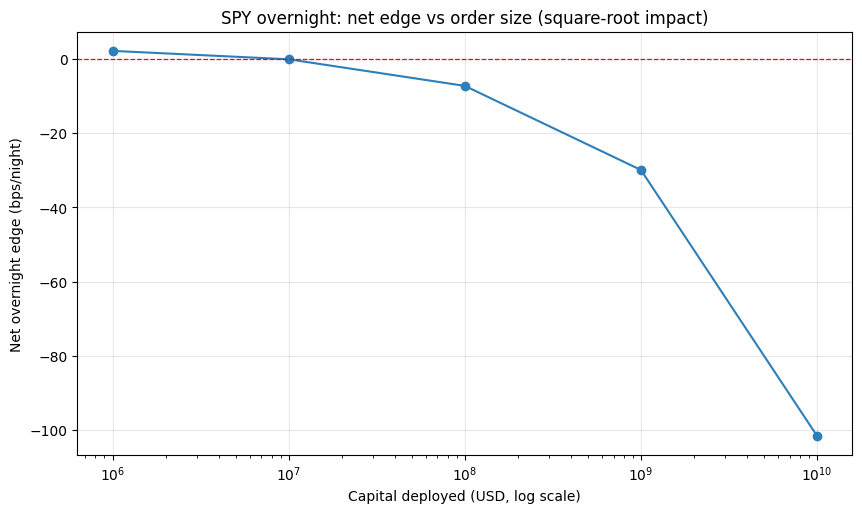

In [13]:
sizes = [1e6, 1e7, 1e8, 1e9, 1e10]
cc = analytics.capacity_curve(decs['SPY'], spy_ohlc, sizes_usd=sizes)
lab = [f'${s/1e6:,.0f}M' if s < 1e9 else f'${s/1e9:,.0f}B' for s in cc.index]
show = cc.copy(); show.index = lab
show.columns = ['participation', 'round-trip impact (bps)', 'net edge (bps)']
display(show.round(2))
ax = plt.subplot()
ax.plot([s for s in sizes], cc['net_edge_bps'].values, marker='o', color='#2c7fb8')
ax.axhline(0, color='r', lw=.9, ls='--')
ax.set_xscale('log'); ax.set_xlabel('Capital deployed (USD, log scale)')
ax.set_ylabel('Net overnight edge (bps/night)')
ax.set_title('SPY overnight: net edge vs order size (square-root impact)')
ax.grid(alpha=.3); plt.show()

The edge is **break-even by ~\$10M and deeply negative beyond \$100M**. A fund deploying billions — the scale required to *move world markets* — would face round-trip impact an order of magnitude larger than the 3-bps premium it is trying to harvest. The alleged mechanism doesn't just fail to scale; **it inverts**: at size, you *pay* the spread you're accused of capturing.

### 6.1 The steelman manipulator — granting the thesis, then pricing it

Let's *steelman* Knuteson all the way: build the alleged firm that round-trips to harvest the overnight, **grant it the entire drift on its capital**, and charge it only round-trip temporary impact (permanent impact nets to zero over a symmetric round trip — the no-dynamic-arbitrage condition of Huberman & Stanzl 2004; Gatheral 2010). Can it profit at the scale required to *move world markets*?

,participation,net_bps_on_capital,net_usd_per_year
$1M,0.000,2.200,"55,531.760"
$10M,0.000,-0.060,"-15,977.580"
$100M,0.000,-7.230,"-18,225,714.340"
$1B,0.020,-29.900,"-753,552,280.850"
$10B,0.200,-101.590,"-25,601,461,312.990"
$100B,2.000,-328.300,"-827,309,750,558.580"


break-even capital ~ $9.6M


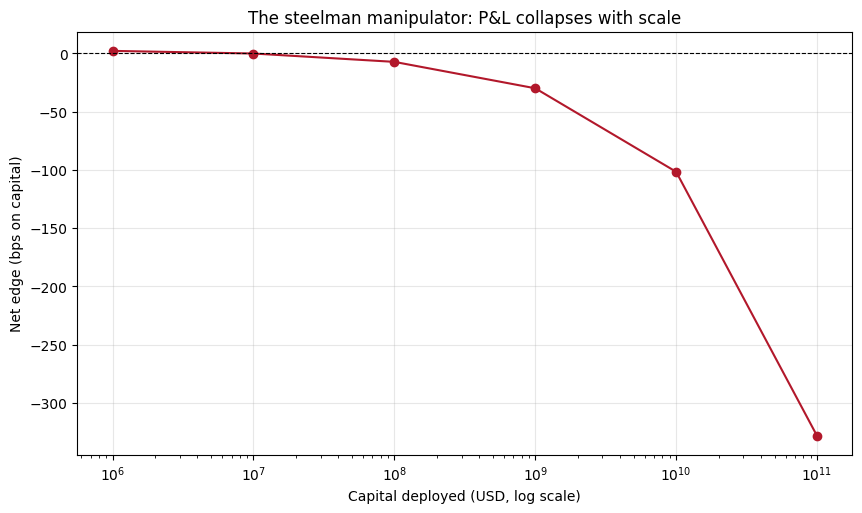

In [14]:
from quantlab import simulate
drift = decs['SPY']['r_overnight'].mean()*1e4
vol   = decs['SPY']['r_close_close'].std(ddof=1)*1e4
adv_usd = float(spy_ohlc['Volume'].tail(252).mean())*float(spy_ohlc['Close'].tail(252).mean())
sizes = [10**e for e in range(6, 12)]
sw = simulate.pnl_vs_capital(drift, adv_usd, vol, sizes_usd=sizes)
be = simulate.breakeven_capital(drift, adv_usd, vol)
disp = sw.copy(); disp.index = [f'${k/1e6:,.0f}M' if k < 1e9 else f'${k/1e9:,.0f}B' for k in sw.index]
display(disp[['participation','net_bps_on_capital','net_usd_per_year']].round(2))
print(f'break-even capital ~ ${be/1e6:,.1f}M')
ax = plt.subplot(); ax.plot(sizes, sw['net_bps_on_capital'].values, marker='o', color='#b2182b')
ax.axhline(0, color='k', ls='--', lw=.8); ax.set_xscale('log')
ax.set_xlabel('Capital deployed (USD, log scale)'); ax.set_ylabel('Net edge (bps on capital)')
ax.set_title('The steelman manipulator: P&L collapses with scale'); ax.grid(alpha=.3); plt.show()

Profitable only at trivial scale; at \$1B it loses hundreds of millions a year, at \$10B tens of billions. **The accused mechanism is economically self-defeating at the size the accusation requires.**

> 💡 **In plain words** — you can't secretly push the whole world's markets around *and* turn a profit on a 3-bps-a-night edge. The pushing costs far more than the edge is worth. So the `MIRAGE` stamp (you can't trade it) and the `NOT SUPPORTED` stamp (nobody big could be doing it) come from the *same* capacity maths.

## 7 · Going further

**What would change the verdict.** Be explicit about our own falsifiability:

- **Toward `manipulation`:** participant-level open-auction order data showing systematic one-book imbalances; characteristic post-open intraday reversals; a firm-specific cross-sectional signature. That's the evidence that would push $\Lambda$ up — and that none of us currently have.
- **Toward `INVESTABLE`:** a residual edge that survives realistic costs *and* scales — e.g. a smarter execution (auction-only, cross-venue) that cuts the 3.3-bps break-even, or a sub-population of names where the per-hour, post-beta, post-decay alpha is genuinely positive. We didn't find one; prove us wrong.

**Reproducibility.** Determinism: synthetic data, bootstrap and all seeds are fixed. Tests: `pytest` checks the decomposition identity `(1+r_night)(1+r_day)=(1+r_cc)` (~1e-16), the cost model, the stats and the analytics (HAC, Lo SE, calendar-time, capacity). CI: GitHub Actions reruns everything on Python 3.10–3.12. Generated notebooks: `python notebooks/build_notebooks.py` then `nbconvert --execute` — every figure here is an executed output, not a screenshot.

**Carry on.** Same data, same engine, new questions — the firm-level cross-section, the weekend effect, post-earnings drift, momentum's overnight/intraday split. New studies follow the same seven beats; the house style is in [METHODOLOGY.md](../../../METHODOLOGY.md). A beautiful, real, and *largely explained* feature of market microstructure — wrongly dressed up as both a free lunch and a global fraud. The honest, fully-reproducible answer is more interesting than either.

## References

Author–date (Chicago / *JFE*). Full list, literature map and BibTeX: [`docs/references.md`](../docs/references.md), [`references.bib`](../references.bib).

Almgren, R., C. Thum, E. Hauptmann, and H. Li. 2005. "Direct Estimation of Equity Market Impact." *Risk* 18 (7). · Berkman, H., P. D. Koch, L. Tuttle, and Y. J. Zhang. 2012. *JFQA* 47 (4): 715–741. · Boyarchenko, N., L. C. Larsen, and P. Whelan. 2023. "The Overnight Drift." *RFS* 36 (9): 3502–3547. · Cooper, M. J., M. T. Cliff, and H. Gulen. 2008. "Like Night and Day." Working paper. · Knuteson, B. 2019–2023. arXiv:1912.01708, 2010.01727, 2201.00223; SSRN 4619084. · Lo, A. W. 2002. "The Statistics of Sharpe Ratios." *FAJ* 58 (4): 36–52. · Lou, D., C. Polk, and S. Skouras. 2019. *JFE* 134 (1): 192–213. · McLean, R. D., and J. Pontiff. 2016. *Journal of Finance* 71 (1): 5–32. · Newey, W. K., and K. D. West. 1987. *Econometrica* 55 (3): 703–708. · Qiao, K., and L. Dam. 2020. *Journal of Financial Markets* 50: 100534.